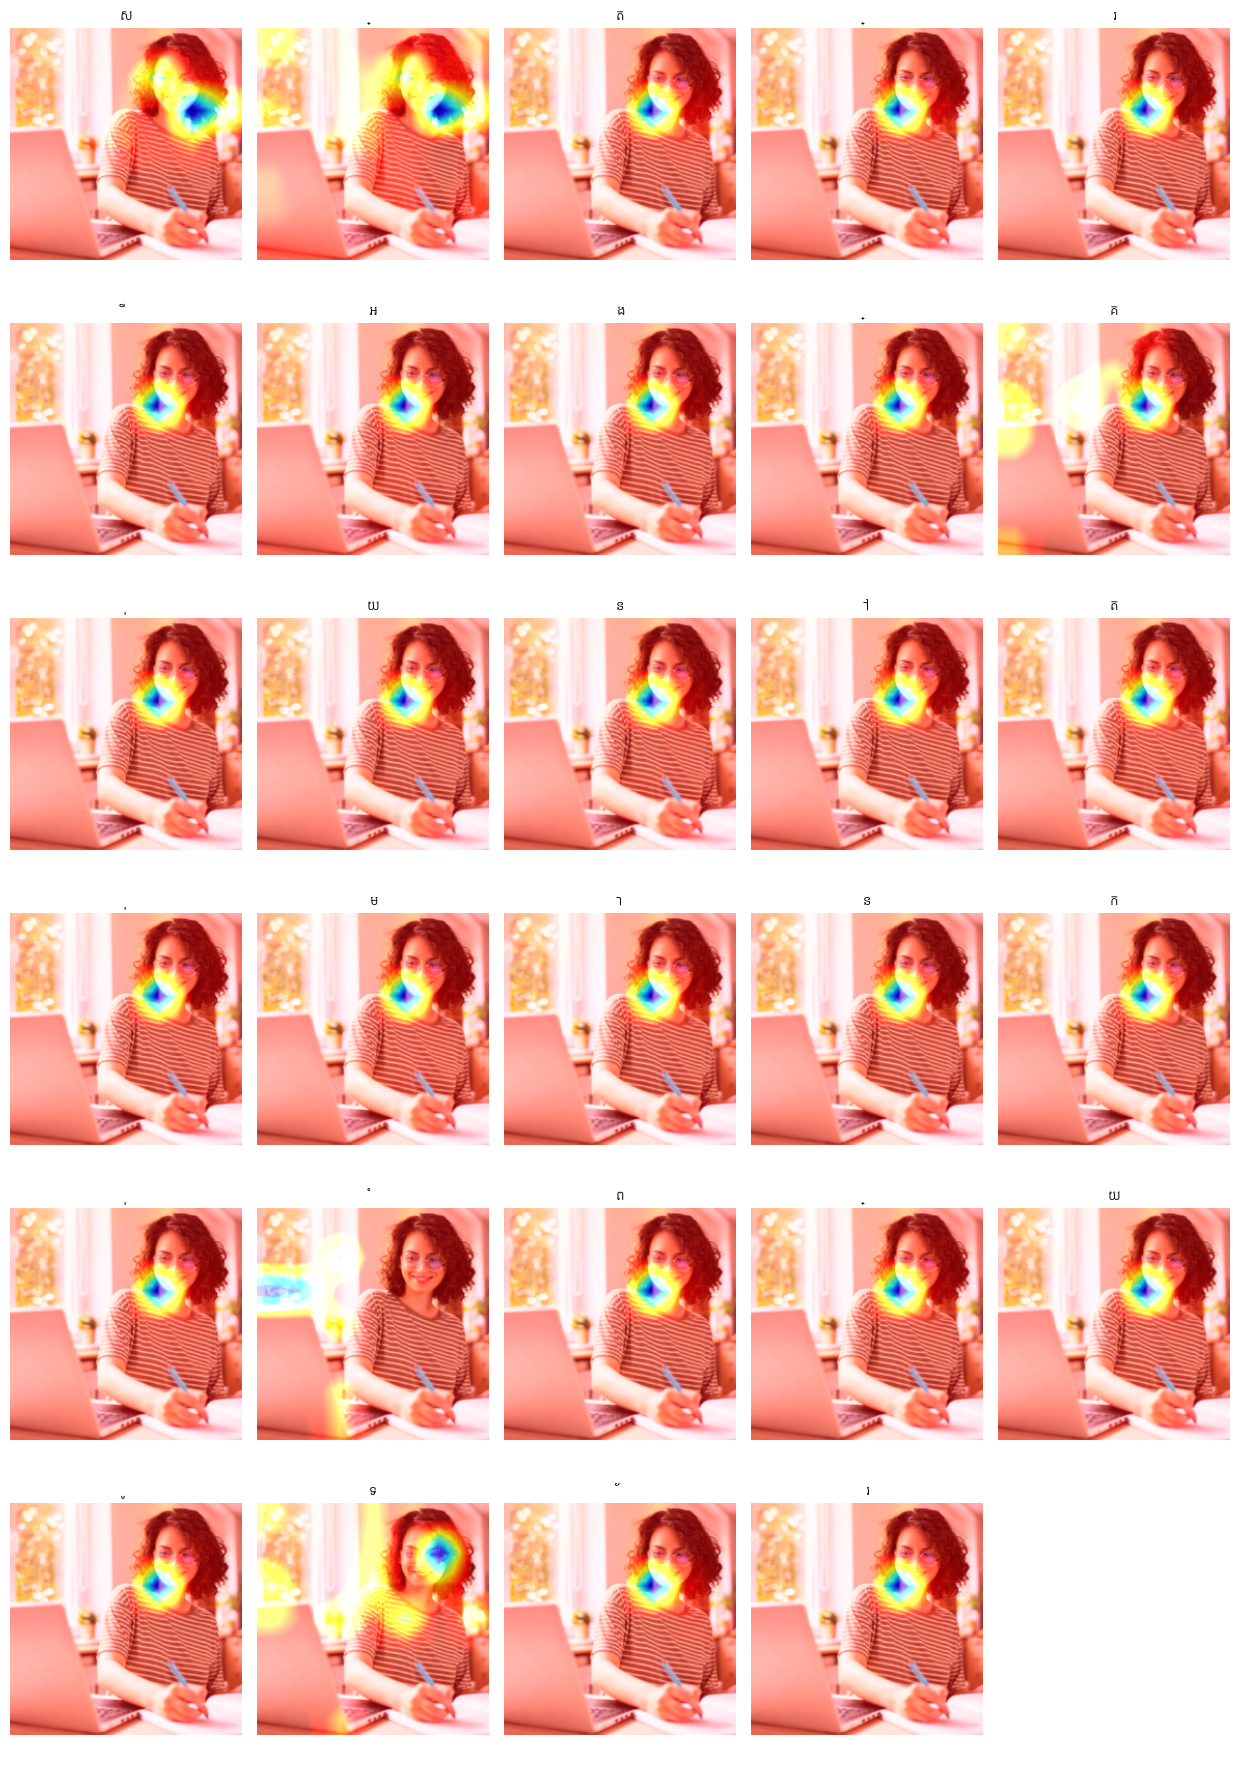

Generated Caption: ស្ត្រីអង្គុយនៅតុមានកុំព្យូទ័រ


In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math



# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

# GradCAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze()
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()

def overlay_heatmap(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    return np.clip(heatmap * 0.8 + img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v2.pth'))
decoder.load_state_dict(torch.load('decoder_final_v2.pth'))
encoder.eval()
decoder.eval()
gradcam = GradCAM(encoder.resnet[-1], encoder.resnet[-1][-1])

# Generate caption and visualize Grad-CAM
def generate_caption_with_gradcam(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)

    tensor_img.requires_grad = True
    encoder_out = encoder(tensor_img)
    h = decoder.init_h(encoder_out.mean(dim=1))
    c = decoder.init_c(encoder_out.mean(dim=1))

    seq = [word2idx['<START>']]
    tokens, heatmaps = [], []

    for _ in range(40):
        last_token = torch.tensor([seq[-1]]).to(device)
        output, h, c = decoder.forward_step(encoder_out, last_token, h, c)
        idx = output.argmax(1).item()
        if idx in [word2idx['<END>'], word2idx['<PAD>']]:
            break
        seq.append(idx)
        tokens.append(idx2word[str(idx)])

        # Backward pass for Grad-CAM
        encoder.zero_grad()
        decoder.zero_grad()
        output[0, idx].backward(retain_graph=True)
        cam = gradcam.generate_cam()
        heatmaps.append(overlay_heatmap(img_for_display, cam))
        
    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    # Define layout
    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    # Flatten axes if needed
    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(heatmaps[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/notebook/image.png'

# Run
caption = generate_caption_with_gradcam(image_path)
print("Generated Caption:", caption)


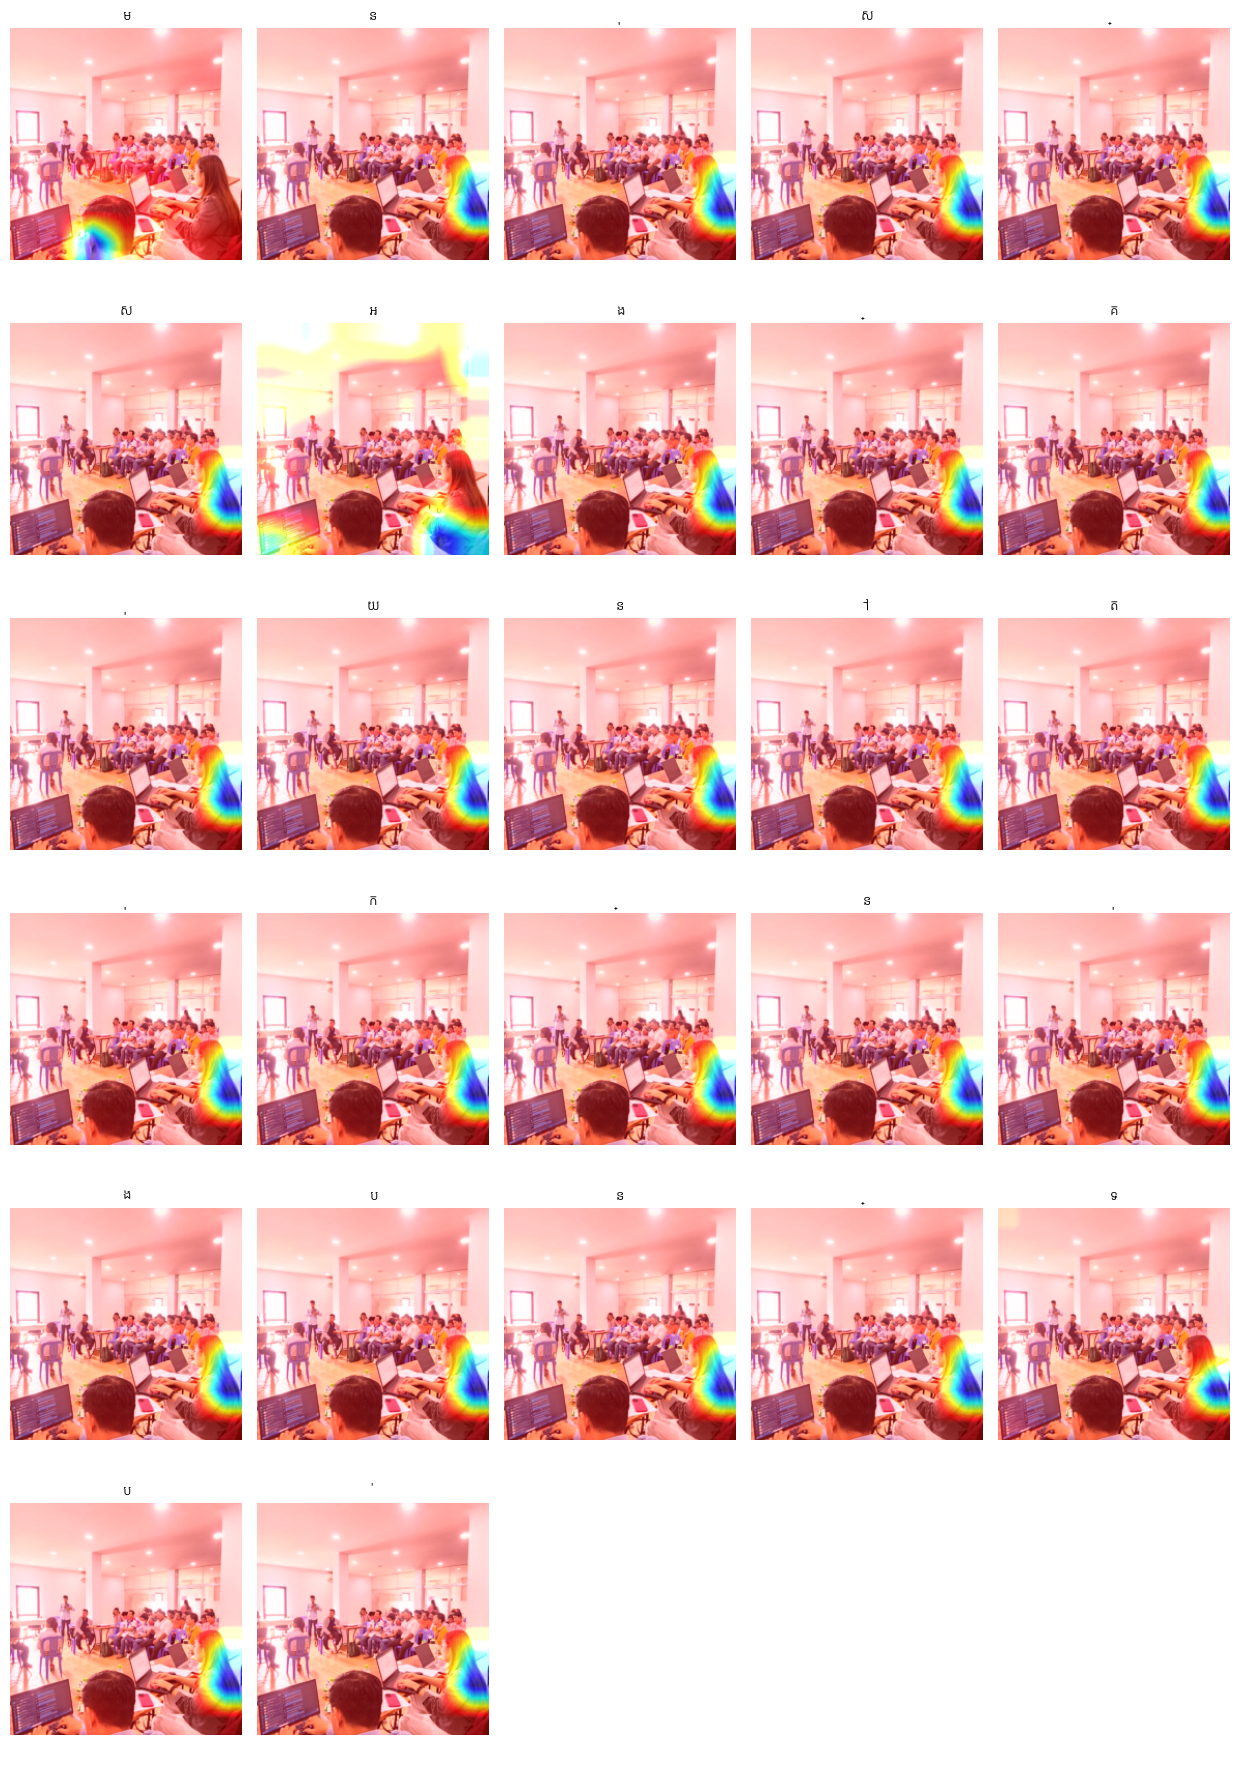

Generated Caption: មនុស្សអង្គុយនៅតុក្នុងបន្ទប់


In [11]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

# GradCAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self):
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam).squeeze()
        cam -= cam.min()
        cam /= cam.max()
        return cam.detach().cpu().numpy()

def overlay_heatmap(img_tensor, cam):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    return np.clip(heatmap * 0.8 + img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v2.pth'))
decoder.load_state_dict(torch.load('decoder_final_v2.pth'))
encoder.eval()
decoder.eval()
gradcam = GradCAM(encoder.resnet[-1], encoder.resnet[-1][-1])

# Generate caption using beam search and visualize Grad-CAM
def generate_caption_with_gradcam(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_heatmaps = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    heatmap_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward_step(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Grad-CAM for top candidate
        decoder.zero_grad()
        encoder.zero_grad()
        outputs[prev_beam_indices[0], next_word_indices[0]].backward(retain_graph=True)
        cam = gradcam.generate_cam()
        heatmap_list[0].append(overlay_heatmap(img_for_display, cam))

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_heatmaps.extend([heatmap_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        heatmap_list = [heatmap_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_heatmaps = complete_heatmaps[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_heatmaps[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/notebook/image.png'

# Run
caption = generate_caption_with_gradcam(image_path)
print("Generated Caption:", caption)


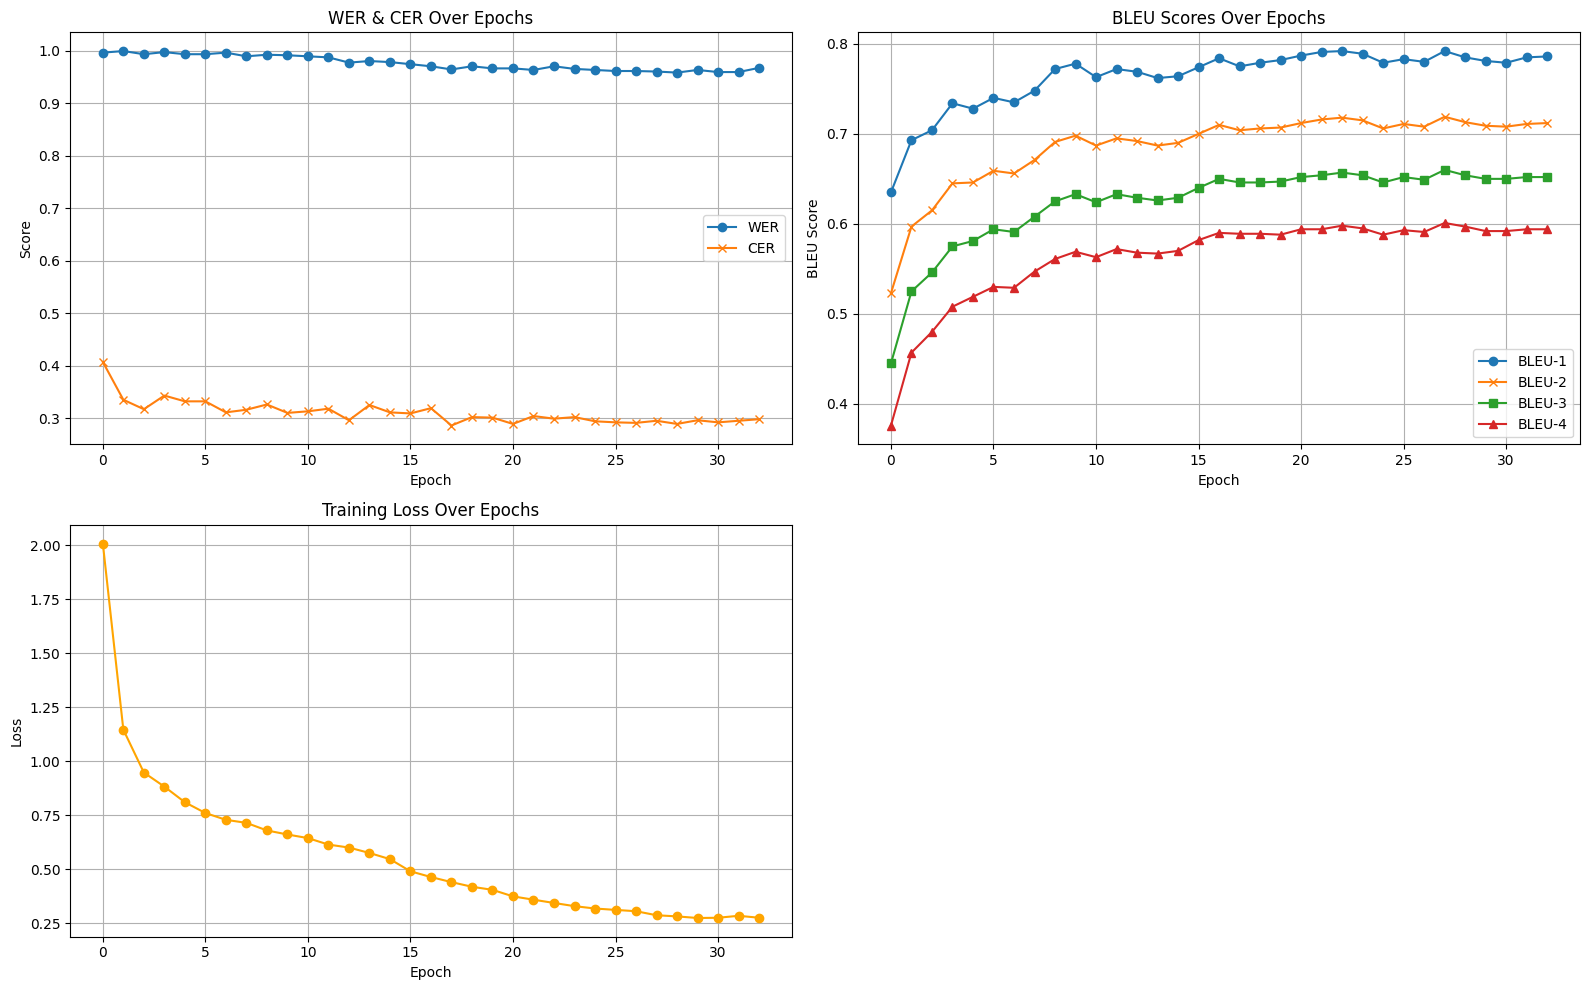

In [12]:
import matplotlib.pyplot as plt

# Training metrics data
train_losses = [
    2.0072, 1.1458, 0.9475, 0.8823, 0.8100, 0.7602, 0.7287, 0.7146, 0.6795,
    0.6608, 0.6441, 0.6141, 0.6003, 0.5753, 0.5467, 0.4904, 0.4639, 0.4403,
    0.4189, 0.4046, 0.3744, 0.3590, 0.3439, 0.3291, 0.3182, 0.3118, 0.3057,
    0.2871, 0.2817, 0.2743, 0.2754, 0.2845, 0.2755
]

wer_scores = [
    0.996, 0.999, 0.993, 0.997, 0.993, 0.993, 0.996, 0.989, 0.992,
    0.991, 0.989, 0.987, 0.977, 0.980, 0.978, 0.974, 0.970, 0.964,
    0.970, 0.966, 0.966, 0.963, 0.970, 0.965, 0.963, 0.961, 0.961,
    0.960, 0.958, 0.963, 0.959, 0.959, 0.967
]
cer_scores = [
    0.407, 0.335, 0.317, 0.343, 0.332, 0.332, 0.311, 0.316, 0.326,
    0.310, 0.313, 0.318, 0.296, 0.325, 0.311, 0.309, 0.319, 0.286,
    0.302, 0.301, 0.289, 0.304, 0.299, 0.302, 0.294, 0.292, 0.291,
    0.295, 0.289, 0.296, 0.292, 0.295, 0.298
]
bleu1_scores = [
    0.635, 0.693, 0.704, 0.734, 0.728, 0.740, 0.735, 0.748, 0.772, 0.778, 0.763,
    0.772, 0.769, 0.762, 0.764, 0.774, 0.784, 0.775, 0.779, 0.782, 0.787, 0.791,
    0.792, 0.789, 0.779, 0.783, 0.780, 0.792, 0.785, 0.781, 0.779, 0.785, 0.786
]

bleu2_scores = [
    0.523, 0.597, 0.615, 0.645, 0.646, 0.659, 0.656, 0.671, 0.691, 0.698, 0.687,
    0.695, 0.692, 0.687, 0.690, 0.700, 0.710, 0.704, 0.706, 0.707, 0.712, 0.716,
    0.718, 0.715, 0.706, 0.711, 0.708, 0.719, 0.713, 0.709, 0.708, 0.711, 0.712
]

bleu3_scores = [
    0.445, 0.525, 0.546, 0.575, 0.581, 0.594, 0.591, 0.608, 0.625, 0.633, 0.624,
    0.633, 0.629, 0.626, 0.629, 0.640, 0.650, 0.646, 0.646, 0.647, 0.652, 0.654,
    0.657, 0.654, 0.646, 0.652, 0.649, 0.660, 0.654, 0.650, 0.650, 0.652, 0.652
]

bleu4_scores = [
    0.376, 0.457, 0.480, 0.508, 0.519, 0.530, 0.529, 0.547, 0.561, 0.569, 0.563,
    0.572, 0.568, 0.567, 0.570, 0.582, 0.590, 0.589, 0.589, 0.588, 0.594, 0.594,
    0.598, 0.595, 0.588, 0.593, 0.591, 0.601, 0.597, 0.592, 0.592, 0.594, 0.594
]


epochs = list(range(len(train_losses)))

# Plotting
plt.figure(figsize=(16, 10))

# WER and CER
plt.subplot(2, 2, 1)
plt.plot(epochs, wer_scores, label='WER', marker='o')
plt.plot(epochs, cer_scores, label='CER', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('WER & CER Over Epochs')
plt.legend()
plt.grid(True)

# BLEU Scores
plt.subplot(2, 2, 2)
plt.plot(epochs, bleu1_scores, label='BLEU-1', marker='o')
plt.plot(epochs, bleu2_scores, label='BLEU-2', marker='x')
plt.plot(epochs, bleu3_scores, label='BLEU-3', marker='s')
plt.plot(epochs, bleu4_scores, label='BLEU-4', marker='^')
plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.title('BLEU Scores Over Epochs')
plt.legend()
plt.grid(True)

# Training Loss
plt.subplot(2, 2, 3)
plt.plot(epochs, train_losses, label='Train Loss', color='orange', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True)

plt.tight_layout()
plt.savefig("training_evaluation_metrics_finalv2.png", dpi=300)
plt.show()


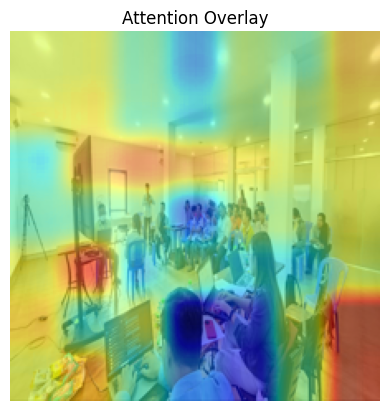

In [12]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# --- Load and preprocess image ---
img_path = "/home/vitoupro/code/image_captioning/notebook/image.png"
image = Image.open(img_path).convert("RGB")
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_tensor = transform(image).unsqueeze(0)

# --- Extract features with ResNet ---
resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-2])
with torch.no_grad():
    features = resnet(image_tensor)
    pooled = torch.nn.AdaptiveAvgPool2d((14, 14))(features)
    encoder_out = pooled.permute(0, 2, 3, 1).reshape(1, -1, 2048)

# --- Dummy attention ---
hidden = torch.randn(1, 512)
attn_layer = torch.nn.Linear(2048 + 512, 256)
v_layer = torch.nn.Linear(256, 1)

h_rep = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
combined = torch.cat((encoder_out, h_rep), dim=2)
energy = torch.tanh(attn_layer(combined))
attn_scores = v_layer(energy).squeeze(2)
alpha = F.softmax(attn_scores, dim=1)

# --- Visualize ---
alpha_2d = alpha[0].view(14, 14).detach().numpy()
heatmap = Image.fromarray(np.uint8(alpha_2d / alpha_2d.max() * 255)).resize((224, 224))
fig, ax = plt.subplots()
ax.imshow(image.resize((224, 224)))
ax.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Attention Overlay")
plt.axis("off")
plt.show()


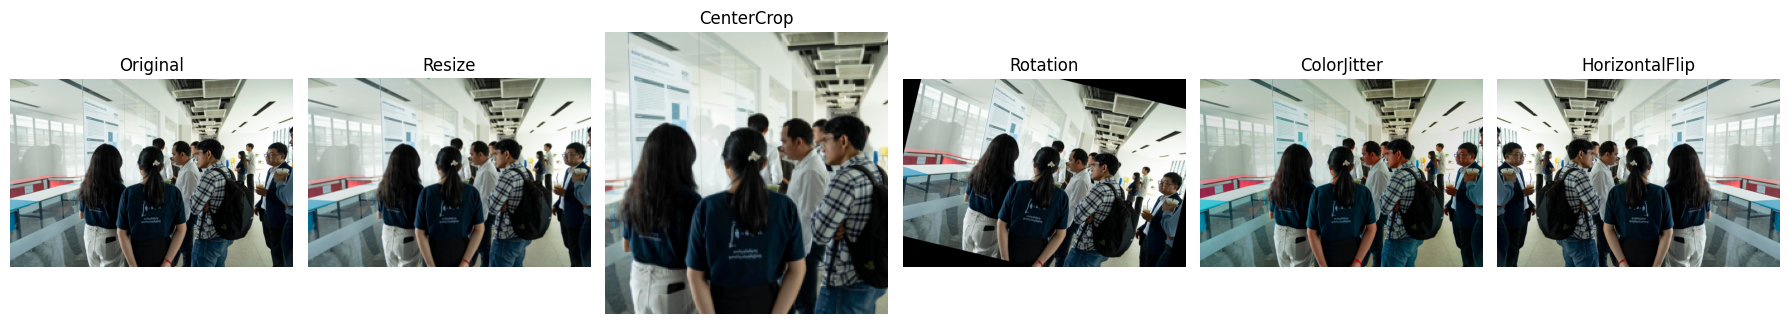

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import random
import torch

# Load the original image
img_path = '/home/vitoupro/code/image_captioning/data/404843922_665977545724158_8925282881131390492_n.jpg'
original_img = Image.open(img_path).convert("RGB")

# Prepare individual transforms
resize = transforms.Resize(256)
center_crop = transforms.CenterCrop(224)
random_rotation = lambda img: TF.rotate(img, angle=random.uniform(-15, 15))
color_jitter = transforms.ColorJitter(brightness=0.8, contrast=0.8)
horizontal_flip = lambda img: TF.hflip(img) if random.random() > 0.5 else img

# Apply each transform to a copy of the image
images = [
    ("Original", original_img),
    ("Resize", resize(original_img)),
    ("CenterCrop", center_crop(resize(original_img))),
    ("Rotation", random_rotation(original_img)),
    ("ColorJitter", color_jitter(original_img)),
    ("HorizontalFlip", horizontal_flip(original_img)),
]

# Plot all images
plt.figure(figsize=(18, 4))
for i, (name, img) in enumerate(images):
    plt.subplot(1, len(images), i + 1)
    # Convert to numpy array if it's a tensor
    if isinstance(img, torch.Tensor):
        img = TF.to_pil_image(img)
    plt.imshow(img)
    plt.axis('off')
    plt.title(name)

plt.tight_layout()
plt.show()


In [3]:
print("✅ Encoder Type:", type(encoder)) 
print("✅ Number of Parameters in Encoder:", sum(p.numel() for p in encoder.parameters()))
print("✅ Number of Trainable Parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))

print("✅ Decoder Type:", type(decoder))
print("✅ Number of Parameters in Decoder:", sum(p.numel() for p in decoder.parameters()))
print("✅ Number of Trainable Parameters:", sum(p.numel() for p in decoder.parameters() if p.requires_grad))


✅ Encoder Type: <class '__main__.EncoderCNN'>
✅ Number of Parameters in Encoder: 23508032
✅ Number of Trainable Parameters: 14964736
✅ Decoder Type: <class '__main__.DecoderRNN'>
✅ Number of Parameters in Decoder: 8579143
✅ Number of Trainable Parameters: 8579143


/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vitoupro/code/image_captioning/image_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


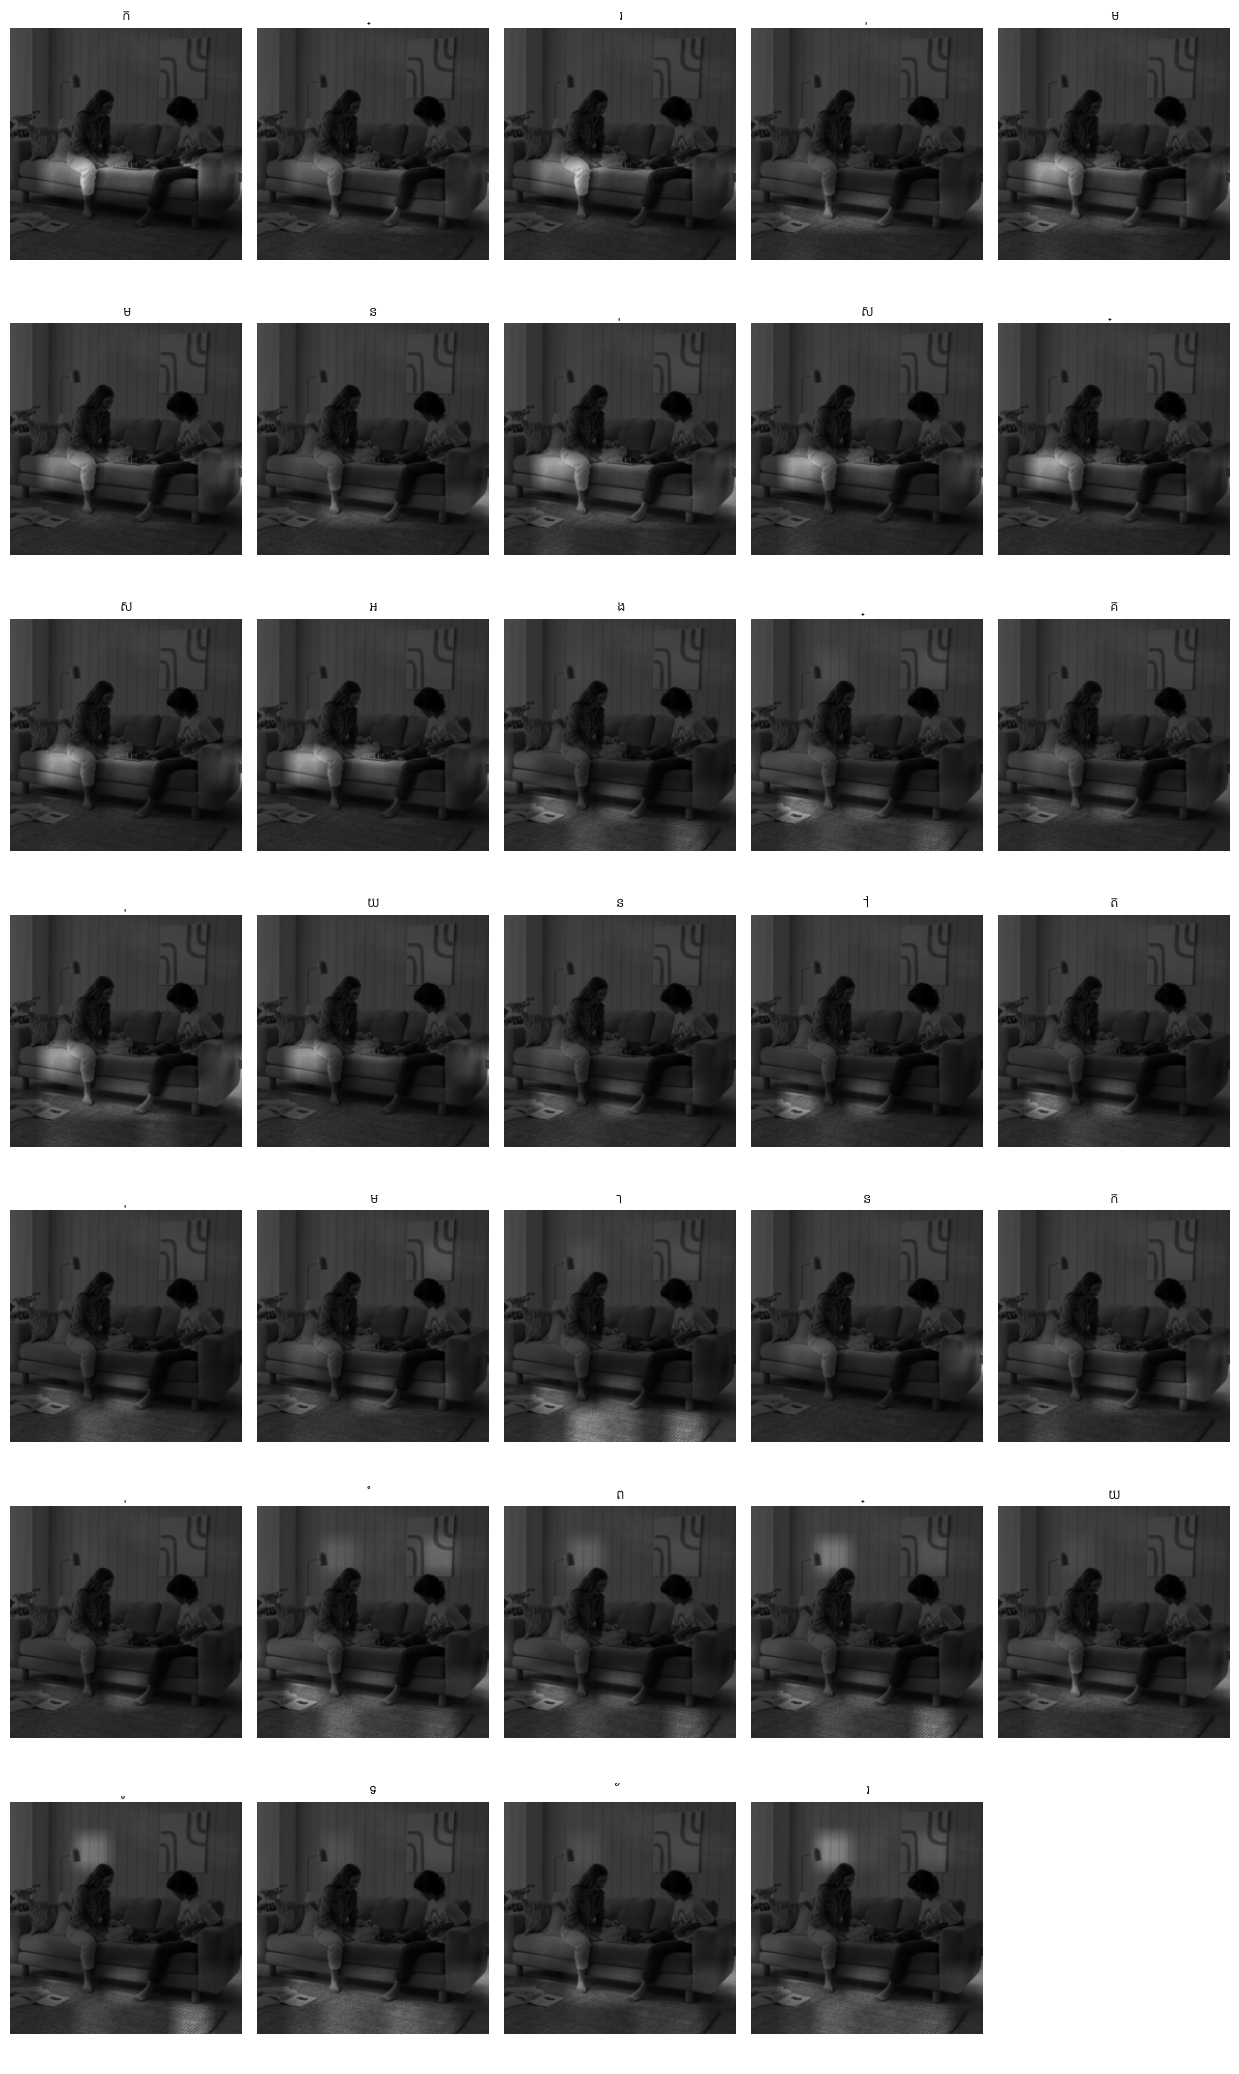

Generated Caption: ក្រុមមនុស្សអង្គុយនៅតុមានកុំព្យូទ័រ


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

# Attention module
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

# Encoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1)
        features = features.view(features.size(0), -1, features.size(-1))
        return features

# Decoder
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=256, encoder_dim=2048):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward_step(self, encoder_out, last_token, h, c):
        embedded = self.dropout(self.embed(last_token))
        context, _ = self.attention(encoder_out, h)
        lstm_input = torch.cat([embedded, context], dim=1)
        h, c = self.lstm(lstm_input, (h, c))
        output = self.linear(h)
        return output, h, c

def create_soft_spotlight(img_tensor, attention_map):
    """Create a soft spotlight overlay using gray-to-white gradient"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    # Resize attention map to match image dimensions
    attention_resized = cv2.resize(attention_map, (img.shape[1], img.shape[0]))
    
    # Normalize attention to 0-1 range
    attention_norm = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Create spotlight effect: gray background with white highlights
    # Convert to grayscale first
    img_gray = np.dot(img, [0.299, 0.587, 0.114])
    img_gray = np.stack([img_gray] * 3, axis=-1)  # Convert back to 3-channel
    
    # Create spotlight mask: 0.3 (dark gray) to 1.0 (white)
    spotlight_intensity = 0.3 + 0.7 * attention_norm
    spotlight_mask = np.stack([spotlight_intensity] * 3, axis=-1)
    
    # Apply spotlight effect
    spotlighted_img = img_gray * spotlight_mask
    
    return np.clip(spotlighted_img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v2.pth'))
decoder.load_state_dict(torch.load('decoder_final_v2.pth'))
encoder.eval()
decoder.eval()

# Generate caption using beam search and visualize attention with soft spotlight
def generate_caption_with_spotlight(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_spotlights = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    spotlight_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward_step(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Generate attention spotlight for top candidate
        with torch.no_grad():
            _, alpha = decoder.attention(encoder_out, h)  # (k, 196)
            attention_map = alpha[0].view(14, 14).cpu().numpy()
            spotlight_img = create_soft_spotlight(img_for_display, attention_map)
            spotlight_list[0].append(spotlight_img)

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_spotlights.extend([spotlight_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        spotlight_list = [spotlight_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_spotlights = complete_spotlights[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_spotlights[i])
            ax.set_title(tokens[i], fontsize=300, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/16.png'

# Run
caption = generate_caption_with_spotlight(image_path)
print("Generated Caption:", caption)


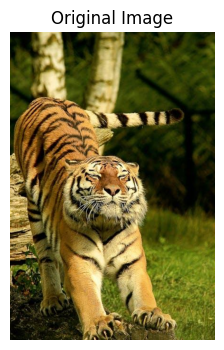

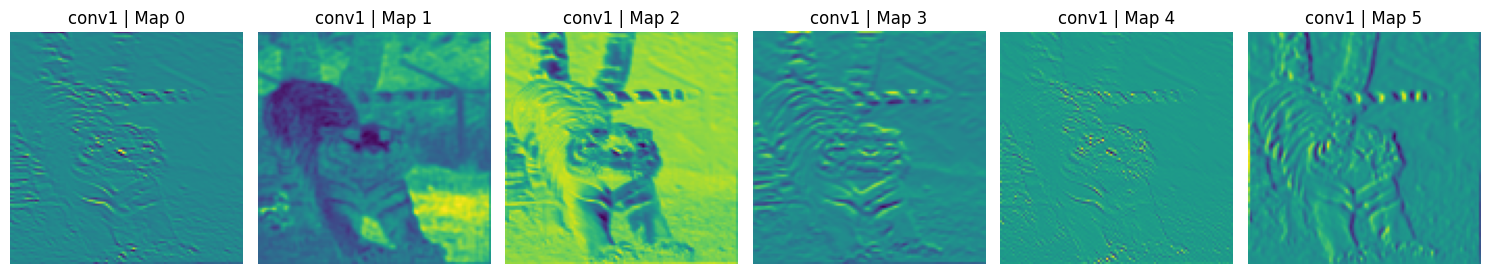

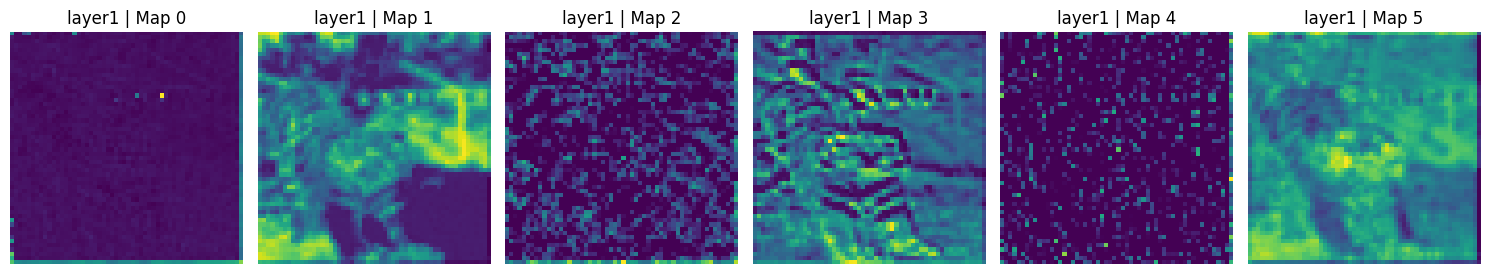

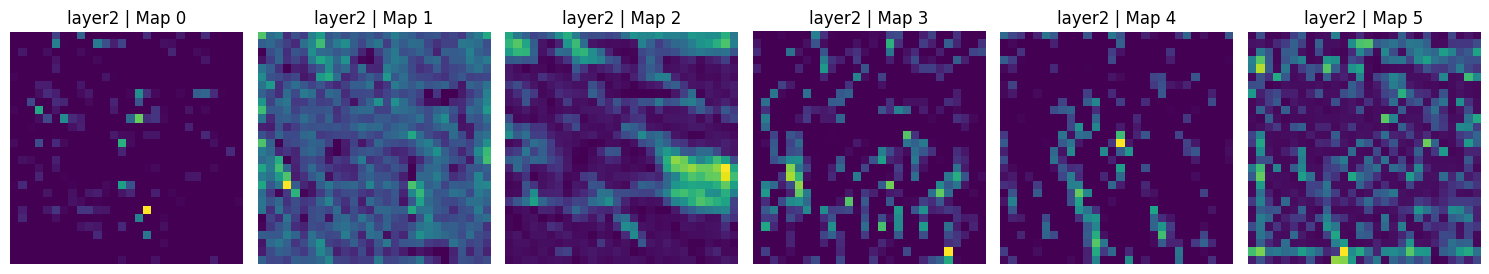

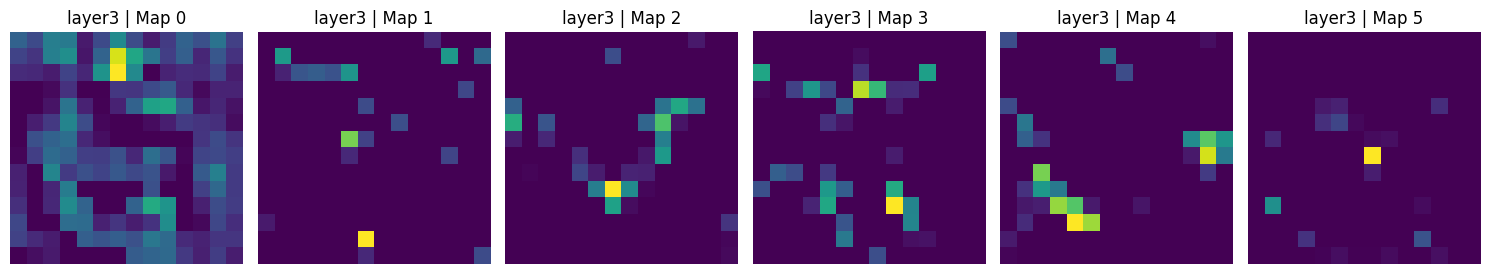

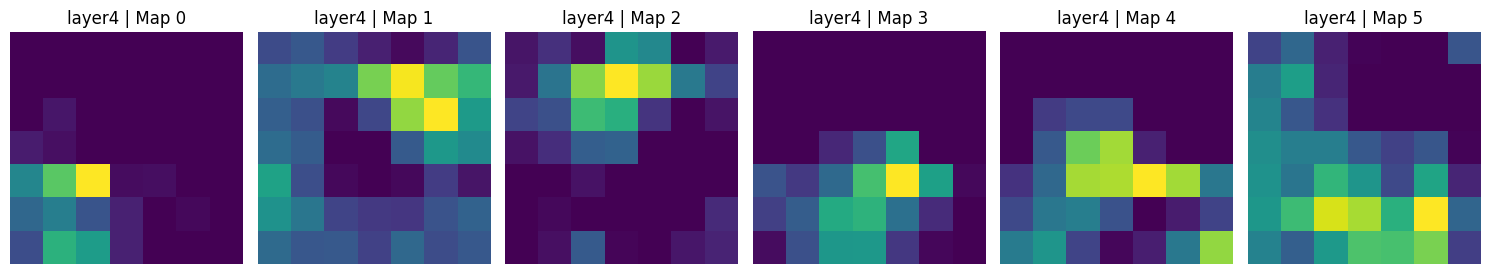

In [10]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Load and preprocess image
image_path = "/home/vitoupro/code/image_captioning/data/pexels_17.jpg"
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
input_tensor = transform(image).unsqueeze(0)  # Add batch dim

# Load ResNet and register hooks
resnet = models.resnet50(pretrained=True)
resnet.eval()

activations = {}
def get_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach()
    return hook

layers = {
    "conv1": resnet.conv1,
    "layer1": resnet.layer1,
    "layer2": resnet.layer2,
    "layer3": resnet.layer3,
    "layer4": resnet.layer4,
}
for name, layer in layers.items():
    layer.register_forward_hook(get_hook(name))

# Forward pass
with torch.no_grad():
    _ = resnet(input_tensor)

# Plot original image
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Plot function
def show_feature_maps(tensor, layer_name, num_maps=6):
    fmap = tensor.squeeze(0)  # remove batch
    plt.figure(figsize=(15, 5))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i+1)
        plt.imshow(fmap[i].cpu(), cmap='viridis')
        plt.title(f"{layer_name} | Map {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Visualize maps from each layer
for name in layers.keys():
    show_feature_maps(activations[name], name)


In [5]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib import font_manager as fm
import math

# Function to load idx2word and convert it to word2idx
def load_vocabulary(path):
    with open(path, 'r') as file:
        idx2word = json.load(file)
    word2idx = {v: int(k) for k, v in idx2word.items()}
    return idx2word, word2idx

# Load vocabulary
idx2word_path = '/home/vitoupro/code/image_captioning/notebook/idx2word.json'
idx2word, word2idx = load_vocabulary(idx2word_path)

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, attention_dim)
        self.v = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, hidden):
        hidden = hidden.unsqueeze(1).repeat(1, encoder_out.size(1), 1)
        attn_input = torch.cat((encoder_out, hidden), dim=2)
        energy = torch.tanh(self.attn(attn_input))
        attention = self.v(energy).squeeze(2)
        alpha = torch.softmax(attention, dim=1)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class EncoderCNN(nn.Module):
    def __init__(self):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for name, param in resnet.named_parameters():
            param.requires_grad = 'layer4' in name
        
        # Extract layers for multi-level feature extraction
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool  # First block max pooling
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        # Adaptive pooling for different feature levels
        self.adaptive_pool_early = nn.AdaptiveAvgPool2d((7, 7))  # For early features
        self.adaptive_pool_late = nn.AdaptiveAvgPool2d((7, 7))   # For late features
        
        # Projection layers to match dimensions
        self.early_proj = nn.Linear(64, 512)  # maxpool output is 64 channels
        self.late_proj = nn.Linear(2048, 1536)  # layer4 output is 2048 channels
        
        # Final feature dimension: 512 + 1536 = 2048 (keeping same as original)

    def forward(self, images):
        # Forward through early layers
        x = self.conv1(images)
        x = self.bn1(x)
        x = self.relu(x)
        early_features = self.maxpool(x)  # Shape: [batch, 64, 56, 56]
        
        # Continue through remaining layers
        x = self.layer1(early_features)
        x = self.layer2(x)
        x = self.layer3(x)
        late_features = self.layer4(x)  # Shape: [batch, 2048, 7, 7]
        
        # Pool and reshape early features
        early_pooled = self.adaptive_pool_early(early_features)  # [batch, 64, 7, 7]
        early_flat = early_pooled.permute(0, 2, 3, 1).reshape(-1, 7*7, 64)  # [batch, 49, 64]
        early_projected = self.early_proj(early_flat)  # [batch, 49, 512]
        
        # Pool and reshape late features
        late_pooled = self.adaptive_pool_late(late_features)  # [batch, 2048, 7, 7]
        late_flat = late_pooled.permute(0, 2, 3, 1).reshape(-1, 7*7, 2048)  # [batch, 49, 2048]
        late_projected = self.late_proj(late_flat)  # [batch, 49, 1536]
        
        # Concatenate features
        combined_features = torch.cat([early_projected, late_projected], dim=2)  # [batch, 49, 2048]
        
        return combined_features
    
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim=512, encoder_dim=2048, num_layers=1, dropout_prob=0.3):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.attention = Attention(encoder_dim, hidden_size, attention_dim)
        self.lstm = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

    def forward(self, encoder_out, captions):
        batch_size = encoder_out.size(0)
        seq_len = captions.size(1)
        vocab_size = self.linear.out_features

        # Init hidden state and cell state
        h = self.init_h(encoder_out.mean(dim=1))  # (B, hidden_size)
        c = self.init_c(encoder_out.mean(dim=1))

        outputs = torch.zeros(batch_size, seq_len - 1, vocab_size).to(encoder_out.device)

        for t in range(seq_len - 1):
            embeddings = self.dropout(self.embed(captions[:, t]))  # (B, embed_size)
            context, _ = self.attention(encoder_out, h)            # (B, encoder_dim)
            lstm_input = torch.cat([embeddings, context], dim=1)   # (B, embed + encoder_dim)
            h, c = self.lstm(lstm_input, (h, c))                   # LSTMCell
            output = self.linear(self.dropout(h))                 # (B, vocab_size)
            outputs[:, t, :] = output

        return outputs

def create_soft_spotlight(img_tensor, attention_map):
    """Create a soft spotlight overlay using gray-to-white gradient"""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    
    # Resize attention map to match image dimensions
    attention_resized = cv2.resize(attention_map, (img.shape[1], img.shape[0]))
    
    # Normalize attention to 0-1 range
    attention_norm = (attention_resized - attention_resized.min()) / (attention_resized.max() - attention_resized.min() + 1e-8)
    
    # Create spotlight effect: gray background with white highlights
    # Convert to grayscale first
    img_gray = np.dot(img, [0.299, 0.587, 0.114])
    img_gray = np.stack([img_gray] * 3, axis=-1)  # Convert back to 3-channel
    
    # Create spotlight mask: 0.3 (dark gray) to 1.0 (white)
    spotlight_intensity = 0.3 + 0.7 * attention_norm
    spotlight_mask = np.stack([spotlight_intensity] * 3, axis=-1)
    
    # Apply spotlight effect
    spotlighted_img = img_gray * spotlight_mask
    
    return np.clip(spotlighted_img, 0, 1)

# Model & device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder = EncoderCNN().to(device)
decoder = DecoderRNN(embed_size=256, hidden_size=512, vocab_size=len(word2idx)).to(device)
encoder.load_state_dict(torch.load('encoder_final_v4.pth'))
decoder.load_state_dict(torch.load('decoder_final_v4.pth'))
encoder.eval()
decoder.eval()

# Generate caption using beam search and visualize attention with soft spotlight
def generate_caption_with_spotlight(image_path, beam_size=5):
    image = Image.open(image_path).convert("RGB")
    tensor_img = transform(image).unsqueeze(0).to(device)
    img_for_display = transform(image).to(device)
    encoder_out = encoder(tensor_img)

    k = beam_size
    vocab_size = len(word2idx)

    seqs = torch.LongTensor([[word2idx['<START>']]] * k).to(device)
    scores = torch.zeros(k, 1).to(device)
    complete_seqs, complete_scores, complete_spotlights = [], [], []
    h = decoder.init_h(encoder_out.mean(dim=1).expand(k, -1))
    c = decoder.init_c(encoder_out.mean(dim=1).expand(k, -1))
    encoder_out = encoder_out.expand(k, -1, -1)
    spotlight_list = [[] for _ in range(k)]

    for _ in range(40):
        last_words = seqs[:, -1]
        outputs, h, c = decoder.forward(encoder_out, last_words, h, c)
        log_probs = torch.log_softmax(outputs, dim=1)
        scores_expanded = scores + log_probs
        scores_topk, topk_indices = scores_expanded.view(-1).topk(k, dim=0)

        prev_beam_indices = topk_indices // vocab_size
        next_word_indices = topk_indices % vocab_size

        seqs = torch.cat([seqs[prev_beam_indices], next_word_indices.unsqueeze(1)], dim=1)
        scores = scores_topk.unsqueeze(1)
        h = h[prev_beam_indices]
        c = c[prev_beam_indices]
        encoder_out = encoder_out[prev_beam_indices]

        # Generate attention spotlight for top candidate
        with torch.no_grad():
            _, alpha = decoder.attention(encoder_out, h)  # (k, 196)
            attention_map = alpha[0].view(14, 14).cpu().numpy()
            spotlight_img = create_soft_spotlight(img_for_display, attention_map)
            spotlight_list[0].append(spotlight_img)

        incomplete_inds = [i for i, next_word in enumerate(next_word_indices) if next_word != word2idx['<END>']]
        complete_inds = list(set(range(len(next_word_indices))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_scores.extend(scores[complete_inds])
            complete_spotlights.extend([spotlight_list[i] for i in complete_inds])
        k -= len(complete_inds)

        if k == 0:
            break

        seqs = seqs[incomplete_inds]
        scores = scores[incomplete_inds]
        h = h[incomplete_inds]
        c = c[incomplete_inds]
        encoder_out = encoder_out[incomplete_inds]
        spotlight_list = [spotlight_list[i] for i in incomplete_inds]

    best_seq_idx = complete_scores.index(max(complete_scores))
    best_seq = complete_seqs[best_seq_idx]
    best_spotlights = complete_spotlights[best_seq_idx]

    tokens = [idx2word[str(idx)] for idx in best_seq if idx not in [word2idx['<START>'], word2idx['<END>'], word2idx['<PAD>']]]

    khmer_font_path = "/home/vitoupro/code/image_captioning/data/KantumruyPro-VariableFont_wght.ttf"
    khmer_font = fm.FontProperties(fname=khmer_font_path)

    tokens_per_row = 5
    num_rows = math.ceil(len(tokens) / tokens_per_row)
    fig, axes = plt.subplots(num_rows, tokens_per_row, figsize=(tokens_per_row * 2.5, num_rows * 3))

    if num_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(num_rows * tokens_per_row):
        ax = axes[i]
        if i < len(tokens):
            ax.imshow(best_spotlights[i])
            ax.set_title(tokens[i], fontsize=12, fontproperties=khmer_font)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return ''.join(tokens)

# Image path and transform
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])
image_path = '/home/vitoupro/code/image_captioning/data/6.png'

# Run
caption = generate_caption_with_spotlight(image_path)
print("Generated Caption:", caption)


TypeError: DecoderRNN.forward() takes 3 positional arguments but 5 were given